# Local (windowed) Masserstein decomposition (axis-200-900)

The global Masserstein cost is decomposed into 100 Da windows to find which m/z regions are reconstructed poorly, whether the reconstruction moves intensity between regions, and whether local errors grow from training pixels to held-out images.

## Introduction

For TIC-normalized spectra the training objective is $W_1 = \int |F_{\hat X}(m) - F_X(m)|\,dm$ with the
cumulative intensity $F$. Three local quantities are reported for every window $W$:

* **contribution** $\int_W |F_{\hat X} - F_X|\,dm$. The windows partition the axis, so the contributions of
  a pixel sum exactly to its global $W_1$ (checked during precompute). A contribution also contains mass
  transported *through* $W$ because of an imbalance at lower m/z.
* **within-window cost**: $W_1$ between $X$ and $\hat X$ restricted to $W$ and renormalized to unit mass
  there, i.e. the local shape error, independent of how much intensity the window holds.
* **masses** $M_X(W)$ and $M_{\hat X}(W)$ (TIC fraction in the window) and the signed imbalance
  $M_{\hat X}(W) - M_X(W)$; the imbalance entering a window equals the sum of the imbalances of all windows
  below it.

### Assumptions

* `test` pixels come from training images and are spatially correlated with training pixels; `heldout_image`
  pixels come from three images never seen during training. Generalization to new images is therefore judged on
  `heldout_image`, generalization to new pixels on `test`.
* Repetitions differ only in initialization and training seed; they share the split. Five repetitions per axis
  are the experimental units for model-level statements; pixels are not independent units.

        * The within-window cost is undefined (missing) when either restricted mass is below $10^{-3}$ of the TIC;
          windows without recorded signal therefore have no local shape error. `defined_fraction` reports the share
          of pixels with a defined value.

### Notation

* $X \in \mathbb{R}_{\ge 0}^{M}$: TIC-normalized input spectrum on the axis ($M$ bins of 0.55 Da);
  $\hat X = \mathrm{Dec}(\mathrm{Enc}(X))$: its reconstruction (TIC-normalized decoder output).
* $Z = \mathrm{Enc}(X) \in \mathbb{R}^{10}$: latent code; $U$: canonicalized code (bottleneck LayerNorm affine
  removed; rows lie on a sphere of radius $\sqrt{10}$ with zero row sum).
* $\hat Y = \sigma(h(Z)) \in [0, 1]^{C}$: head probabilities of the $C$ train-observed molecule classes.
* $P \in \{\mathrm{train}, \mathrm{test}, \mathrm{test\_extended}, \mathrm{heldout\_image}\}$: pixel population;
  $r = 0, \dots, 4$: repetition (independent training seed of the same configuration).
* $W_1(X, \hat X)$: training Masserstein cost, the exact one-dimensional Wasserstein-1 distance between the
  TIC-normalized spectra, in m/z units.
* Window $W = [a, a + 100)$ m/z, aligned to multiples of 100 on every axis.

        * $C_W$: contribution of window $W$; $w_W$: within-window cost; $\Delta_W = M_{\hat X}(W) - M_X(W)$.

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "reconstruction_windowed"
AXIS = "axis-200-900"

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


LABELS = list(catalog.drop_duplicates("display_label").sort_values("display_order").display_label)
LABEL_COLORS = {label: figures.model_color(label, theme, position) for position, label in enumerate(LABELS)}
POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
CLASS_SET_COLORS = {name: figures.class_set_color(name, theme) for name in figures.CLASS_SET_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| models:", len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

POPULATIONS = ['train', 'test', 'test_extended', 'heldout_image']
AXIS_LABEL = settings['axes'][AXIS]['label']
MODEL_LABEL = catalog[catalog.axis == AXIS].display_label.iloc[0]
DATASETS = sorted(load_table(settings, 'heldout_image_reconstruction', 'image_metrics', AXIS).dataset_id.unique())
print('Axis label:', AXIS_LABEL, '| held-out images:', DATASETS)

windows = table('window_summary')
WINDOW_ORDER = list(windows.drop_duplicates('window_label').sort_values('window_lower').window_label)

Analysis: reconstruction_windowed | axis: axis-200-900 | models: 5
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'inference': '0243c1efb93b9c4c'}
Axis label: 200-900 m/z | held-out images: ['2024-02-20_01h45m20s', '2024-02-20_01h46m58s', '2024-02-20_01h54m41s']


## Producing the tables this notebook reads

### Methodology

#### Implementation

`windowed_masserstein` is evaluated inside the `inference` cache level on every pixel of every population
with the same `SpectrumMasserstein` implementation and TIC normalization as the training objective.
`reconstruction_windowed` summarises the per-pixel window arrays per population, per image and per bin.

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis reconstruction_windowed > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Local shape error per m/z window

### Methodology

#### Theoretical

The within-window cost $w_W$ answers which m/z regions have a poorly reproduced peak pattern regardless of
how much intensity they carry. Its mean and median are compared across populations.

#### Implementation

`window_summary` holds per model, population, window and quantity the distribution statistics over pixels.

#### Figure descriptions

x = window centre (m/z), y = mean (first figure) and median (second figure) within-window cost; colour =
population, one line per repetition. Missing points are windows where the cost is undefined for all pixels.

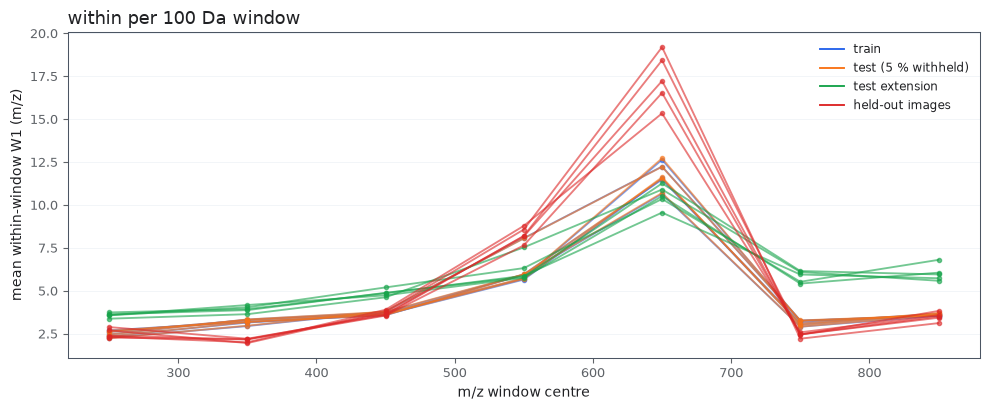

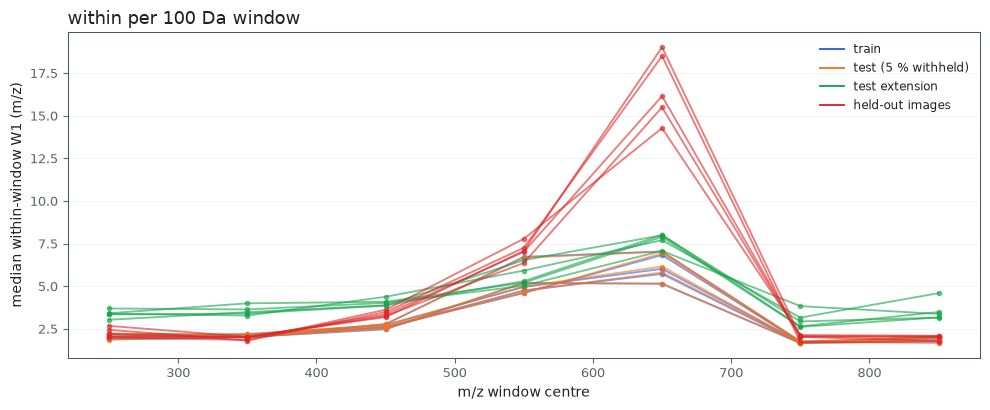

In [3]:
figures.window_profiles(windows, quantity='within', populations=POPULATIONS, statistic='mean', ylabel='mean within-window W1 (m/z)', theme=theme);
figures.window_profiles(windows, quantity='within', populations=POPULATIONS, statistic='median', ylabel='median within-window W1 (m/z)', theme=theme);

In [4]:
defined = windows[windows.quantity == 'within'].pivot_table(index='window_label', columns='population', values='defined_fraction').reindex(WINDOW_ORDER)
display(defined[POPULATIONS].round(3))

population,train,test,test_extended,heldout_image
window_label,,,,
200-300,1.000,1.000,1.000,1.000
300-400,1.000,1.000,1.000,1.000
400-500,1.000,1.000,1.000,1.000
500-600,1.000,0.999,1.000,0.999
600-700,0.865,0.866,0.903,0.728
700-800,0.994,0.993,0.989,1.000
800-900,0.981,0.981,0.990,1.000


### Remarks

- 600-700 m/z has by far the largest local shape error (11.7 on train/test, 17.3 on held-out), followed by 500-600 (6.3 / 8.3). Both windows carry only 5 % of the TIC (held-out: 1.4 % and 0.5 %).
- All other windows lie between 2 and 4 m/z on every population.

### Notes

## Contribution of every window to the global Masserstein cost

### Methodology

#### Theoretical

The contribution $C_W$ localises where the global objective is spent. Its share $C_W / W_1$ per pixel shows
which windows dominate the loss independently of the overall error level.

#### Implementation

Same table as above, quantities `contribution` and `contribution_share` (per-pixel ratio, then averaged).

#### Figure descriptions

First figure: x = window centre, y = mean contribution (m/z); second figure: y = mean share of the pixel's
global cost; colour = population, one line per repetition. The shares of one pixel sum to one.

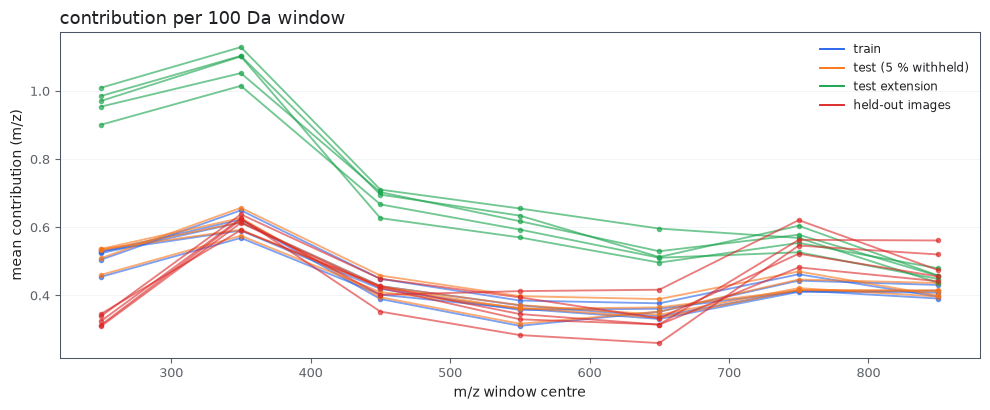

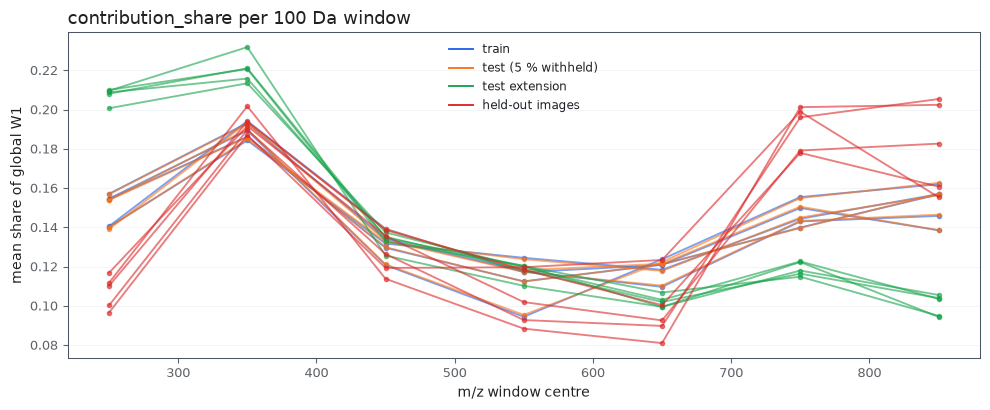

In [5]:
figures.window_profiles(windows, quantity='contribution', populations=POPULATIONS, ylabel='mean contribution (m/z)', theme=theme);
figures.window_profiles(windows, quantity='contribution_share', populations=POPULATIONS, ylabel='mean share of global W1', theme=theme);

### Remarks

- Contributions are spread evenly (0.35-0.61 m/z per window); on held-out images the 700-900 windows contribute more because they hold more intensity there.

### Notes

## Intensity moved between windows

### Methodology

#### Theoretical

A reconstruction can have a small local shape error but place too little or too much intensity in a window.
The signed imbalance $\Delta_W$ measures this directly; a window with input signal but $M_{\hat X}(W) \approx
0$ is a window the decoder empties.

#### Implementation

Quantities `input_mass`, `output_mass` and `mass_imbalance` of `window_summary` (means over pixels).

#### Figure descriptions

First figure: mean input mass (TIC fraction) per window; second: mean reconstruction mass; third: mean signed
imbalance (reconstruction minus input), dashed zero line implicit at y = 0. Colour = population, one line per
repetition.

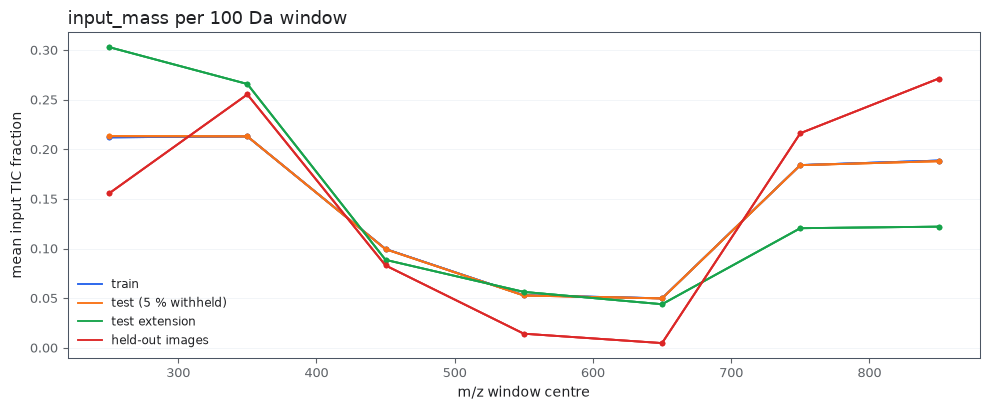

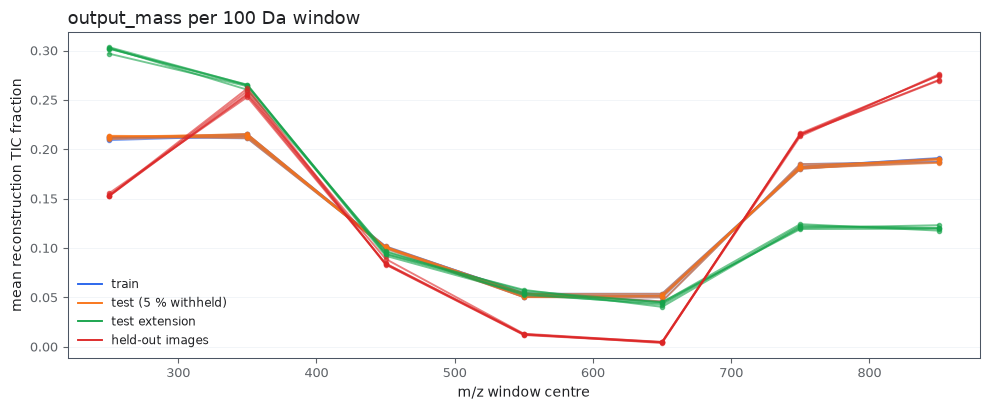

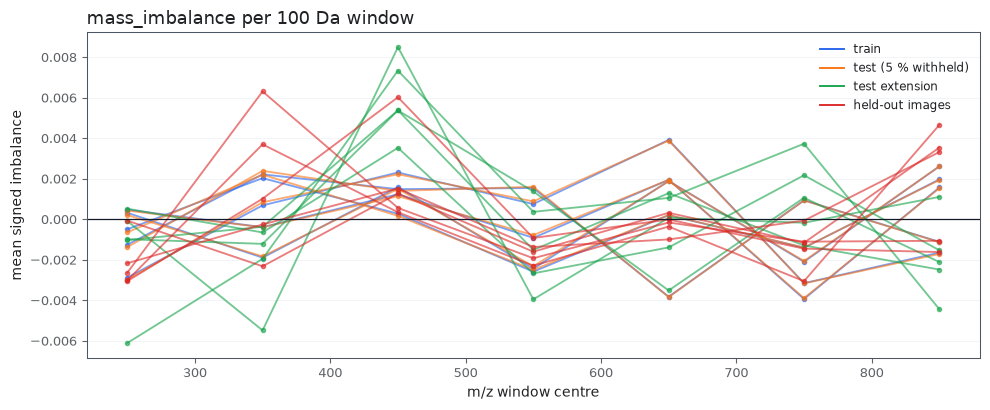

In [6]:
figures.window_profiles(windows, quantity='input_mass', populations=POPULATIONS, ylabel='mean input TIC fraction', theme=theme);
figures.window_profiles(windows, quantity='output_mass', populations=POPULATIONS, ylabel='mean reconstruction TIC fraction', theme=theme);
figure = figures.window_profiles(windows, quantity='mass_imbalance', populations=POPULATIONS, ylabel='mean signed imbalance', theme=theme)
figure.axes[0].axhline(0, color=theme.baseline_color, linewidth=theme.reference_line_width);

### Remarks

- Window masses are reproduced within 0.002 TIC in every window and population: the decoder does not move intensity between regions.

### Notes

## Local error per held-out image

### Methodology

#### Theoretical

Population means can hide an image-specific failure. The mean within-window cost is shown per held-out image
next to the population means of the training images.

#### Implementation

`window_images` holds the mean per model, population, image and window; values are averaged over the five
repetitions for the heat map. Windows without any defined value are omitted.

#### Figure descriptions

Heat map: rows = populations of the training images and the three held-out images, columns = windows,
colour = mean within-window cost (m/z, repetition mean). The second heat map shows held-out minus test per
repetition (rows) and window (columns); red = worse on held-out images.

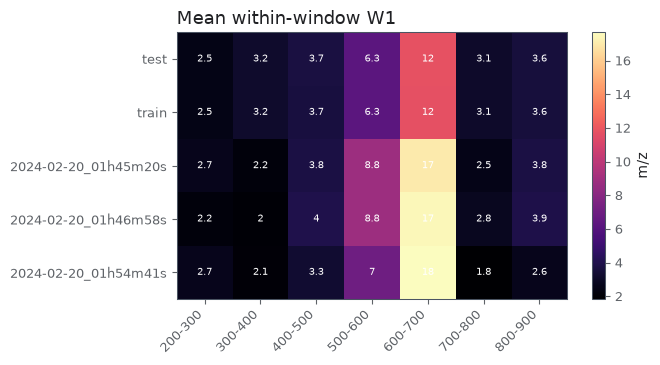

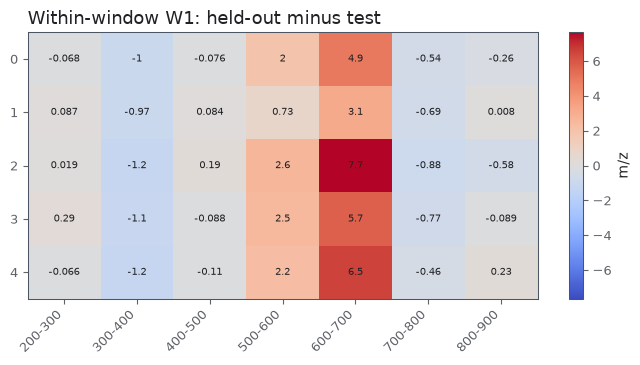

In [7]:
images = table('window_images')
within_images = images[(images.quantity == 'within') & (images.population == 'heldout_image')].pivot_table(index='dataset_id', columns='window_label', values='mean')
within_populations = windows[(windows.quantity == 'within') & windows.population.isin(['train', 'test'])].pivot_table(index='population', columns='window_label', values='mean')
matrix = pd.concat([within_populations, within_images]).reindex(columns=WINDOW_ORDER).dropna(axis=1, how='all')
figures.matrix_heatmap(matrix, title='Mean within-window W1', colorbar_label='m/z', annotate=True, theme=theme);
gaps = table('window_gaps')
gap_matrix = gaps[gaps.quantity == 'within'].pivot_table(index='repetition', columns='window_label', values='heldout_minus_test').reindex(columns=WINDOW_ORDER).dropna(axis=1, how='all')
figures.matrix_heatmap(gap_matrix, title='Within-window W1: held-out minus test', colorbar_label='m/z', diverging=True, annotate=True, theme=theme);

### Remarks

- The 500-700 degradation is present in all three held-out images; 300-400 and 700-800 are reconstructed *better* on held-out images than on test.

### Notes

## Mean error per bin along the axis

### Methodology

#### Theoretical

Within a window the error concentrates on individual peaks. The mean input, mean reconstruction and mean
signed error per bin show which peaks are under- or over-reconstructed on average.

#### Implementation

`feature_errors` holds per model, population, group (all pixels or one held-out image) and bin the mean input,
output and errors; the repetition mean is taken in the figure function.

#### Figure descriptions

Two rows per group: top = mean input (grey) and mean reconstruction (colour) per bin (TIC fraction); bottom =
mean signed error (reconstruction minus input). Groups: all test pixels, all held-out pixels.

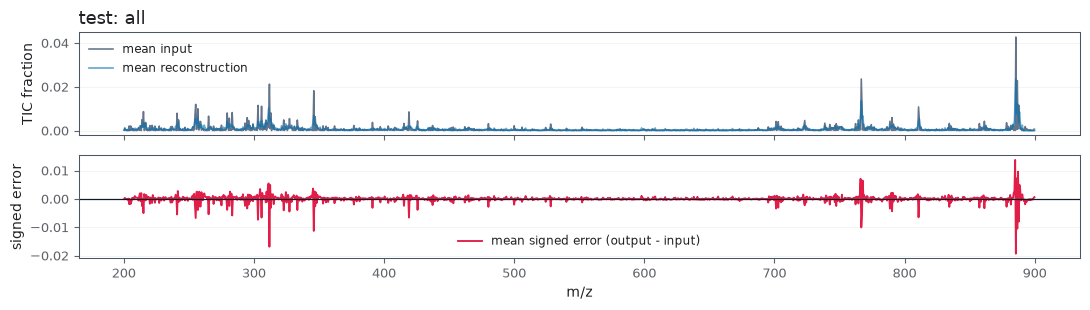

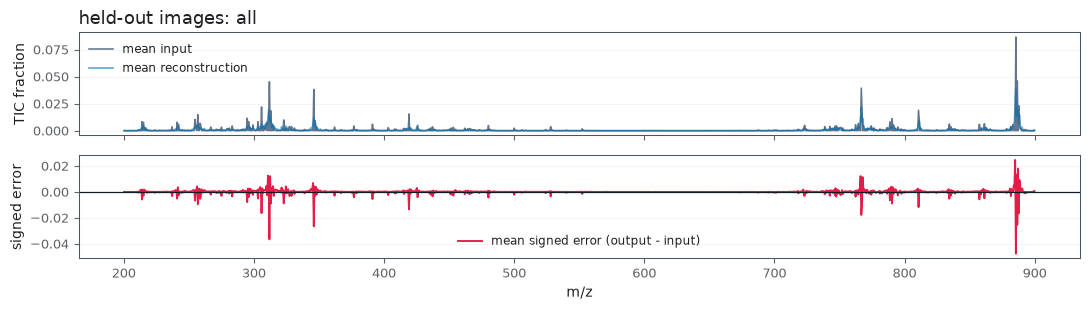

In [8]:
features = table('feature_errors')
figures.feature_profile(features[features.population == 'test'], groups=['all'], title='test', theme=theme);
figures.feature_profile(features[features.population == 'heldout_image'], groups=['all'], title='held-out images', theme=theme);

### Remarks

### Notes

## Results / Summary

### LLM

- **Observed:** local shape error concentrates in 500-700 m/z, the windows with the least signal; it roughly doubles from test to held-out images there (11.8 -> 17.3 in 600-700). Elsewhere the local error is 2-4 m/z and similar across populations.
- **Observed:** intensity is not moved between windows (imbalance below 0.002 TIC).
- **Interpretation:** the model reconstructs the peak-rich regions well and fails where signal is sparse; since those windows carry little mass they contribute little to the global objective, which is why the global W1 hides them.
- **Hypothesis:** the within-window cost of low-mass windows is dominated by noise-level peaks in the input; a signal-weighted local metric would separate model failure from noise.

### Person